In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.tools import aggregate_results

In [3]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def order_models(strings, rev=False):
    return sorted(strings, key=lambda s: (
        s.split('-')[0],  # Model name
        -1 * int(s.split('-')[1][:-1]),  # Param count, B dropped
    ), reverse=rev)

def capitalize(s):
    return s[0].upper() + s[1:]

In [4]:
def my_scatterplot(df, metric_cols):

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # -----------------------------
    # Baselines
    # -----------------------------
    baselines = df[df["suite"] == "0-non-expl"]

    # Remove baselines from plotted data
    df = df[df["suite"] != "0-non-expl"]

    metrics = ["Theme", "Topic", "Concept"]

    # -----------------------------
    # Long format
    # -----------------------------
    plot_df = pd.DataFrame({
        "Model": df["model"].tolist() * 3,
        "metric": (
            ["Theme"] * len(df) +
            ["Topic"] * len(df) +
            ["Concept"] * len(df)
        ),
        "F1 Score": pd.concat(
            [df[col] for col in metric_cols],
            ignore_index=True
        )
    })

    model_order = order_models(df["model"].unique())

    # -----------------------------
    # Scatter plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.stripplot(
        data=plot_df,
        x="Model",
        y="F1 Score",
        hue="metric",
        order=model_order,
        dodge=True,
        jitter=False,
        marker="o",
        size=6,
        alpha=0.7,
        ax=ax
    )

    # -----------------------------
    # Vertical separator lines
    # -----------------------------
    for i in range(len(model_order) - 1):
        ax.axvline(
            x=i + 0.5,
            color="gray",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6,
            zorder=0
        )

    # -----------------------------
    # Baseline dots
    # -----------------------------
    metric_map = {
        "Theme": "theme f1 mean",
        "Topic": "topic f1 mean",
        "Concept": "concept f1 mean"
    }

    n_metrics = len(metrics)
    total_width = 0.8
    hue_width = total_width / n_metrics

    for i, model in enumerate(model_order):

        baseline_row = baselines[baselines["model"] == model]

        if baseline_row.empty:
            continue

        for j, metric in enumerate(metrics):

            baseline_val = baseline_row.iloc[0][metric_map[metric]]

            # Position inside each hue subgroup
            x_center = (
                i
                - total_width / 2
                + hue_width / 2
                + j * hue_width
            )

            ax.scatter(
                x=x_center,
                y=baseline_val,
                color="red",
                s=50,
                edgecolor="black",
                zorder=10
            )

    # -----------------------------
    # Legend cleanup
    # -----------------------------
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], labels[:3], title="Metric")

    plt.tight_layout()

    return ax

In [5]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

res = pd.read_csv("./data/metrics.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

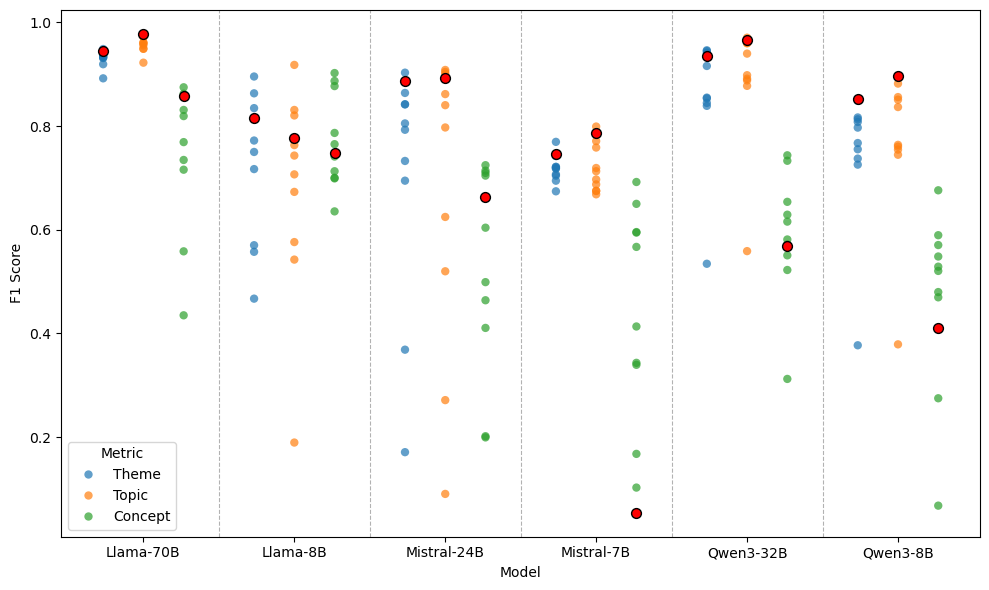

In [10]:
fig = my_scatterplot(res, metric_cols_f1)

#plt.savefig(f"./latex/images/f1_per_model_scatter.png", bbox_inches="tight")
#plt.show()